# 0.0 IMPORTS

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn import preprocessing as pp
from category_encoders import TargetEncoder
from sklearn import model_selection as ms
from sklearn import ensemble as en
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn import neighbors as ng
import sklearn.linear_model as lm
from sklearn.metrics import top_k_accuracy_score
import pickle
from boruta import BorutaPy as bt

## 0.1 Loading dataset

In [3]:
df_raw = pd.read_csv('../data/raw/train.csv')

## 0.2 Herlper Functions

In [4]:
def cumulative_gain_curve(y_true, y_score):
    # ordenar pelas probabilidades (maior → menor)
    order = np.argsort(y_score)[::-1]
    y_true_sorted = np.array(y_true)[order]

    # soma acumulada dos positivos
    cum_gain = np.cumsum(y_true_sorted)

    # normalizar (dividir pelo total de positivos)
    total_positives = np.sum(y_true)
    cum_gain = cum_gain / total_positives

    # eixo x (% da amostra)
    perc = np.arange(1, len(y_true) + 1) / len(y_true)

    return perc, cum_gain


def precision_at_k(data, k=2000):
    data = data.reset_index(drop=True)
    data['ranking'] = data.index + 1
    data['precision_at_k'] = data['response'].cumsum() / data['ranking']

    return data.loc[k - 1, 'precision_at_k'], data


def recall_at_k(data, k=2000):
    data = data.reset_index(drop=True)
    data['ranking'] = data.index + 1
    data['recall_at_k'] = data['response'].cumsum() / data['response'].sum()

    return data.loc[k - 1, 'recall_at_k'], data


# 1.0 DATA DESCRIPTION

## 1.1 Data Dimension

In [5]:
df_raw.columns = df_raw.columns.str.lower()
df1 = df_raw

In [6]:
print('Number of row : {}'.format(df1.shape[0]))
print('Number of columns : {}'.format(df1.shape[1]))

Number of row : 381109
Number of columns : 12


## 1.2 Data Types

In [7]:
df1.dtypes

id                        int64
gender                      str
age                       int64
driving_license           int64
region_code             float64
previously_insured        int64
vehicle_age                 str
vehicle_damage              str
annual_premium          float64
policy_sales_channel    float64
vintage                   int64
response                  int64
dtype: object

## 1.3 Check NA

In [8]:
df1.isna().sum()

id                      0
gender                  0
age                     0
driving_license         0
region_code             0
previously_insured      0
vehicle_age             0
vehicle_damage          0
annual_premium          0
policy_sales_channel    0
vintage                 0
response                0
dtype: int64

## 1.4 Data Descriptive

In [9]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64','datetime64[ns]'])

In [10]:
#central tendency - mediam, mean
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

#dispersion - std, min, max, range, skew, kurtose
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(np.min)).T
d3 = pd.DataFrame(num_attributes.apply(np.max)).T
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T

#concatenar
m = pd.concat([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,id,1.0,381109.0,381108.0,190555.000000,190555.0,110016.691870,0.000000,-1.200000
1,age,20.0,85.0,65.0,38.822584,36.0,15.511591,0.672539,-0.565655
2,driving_license,0.0,1.0,1.0,0.997869,1.0,0.046109,-21.595182,464.354302
3,region_code,0.0,52.0,52.0,26.388807,28.0,13.229871,-0.115266,-0.867857
4,previously_insured,0.0,1.0,1.0,0.458210,0.0,0.498251,0.167747,-1.971871
5,annual_premium,2630.0,540165.0,537535.0,30564.389581,31669.0,17213.132474,1.766087,34.004569
6,policy_sales_channel,1.0,163.0,162.0,112.034295,133.0,54.203924,-0.900008,-0.970810
7,vintage,10.0,299.0,289.0,154.347397,154.0,83.671194,0.003030,-1.200688
8,response,0.0,1.0,1.0,0.122563,0.0,0.327935,2.301906,3.298788


# 2.0 FEATURE ENGINEERING

In [11]:
df2 = df1.copy()

In [12]:
# vehicle age
df2['vehicle_age'] = df2['vehicle_age'].apply(lambda x:'over_2_years' if x== '> 2 Years' else 'between_1_2_years' if x =='1-2 Year' else 'below_1_year')
# vehicle damage
df2['vehicle_damage'] = df2['vehicle_damage'].apply(lambda x:1 if x =='Yes' else 0)

In [13]:
df2.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,Male,44,1,28.0,0,over_2_years,1,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,between_1_2_years,0,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,over_2_years,1,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,below_1_year,0,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,below_1_year,0,27496.0,152.0,39,0


# 3.0 DATA FILTERING

In [14]:
df3 = df2.copy()

# 4.0 EDA

In [15]:
df4 = df3.copy()

## 4.1 Analise univariada

In [16]:
df4.columns

Index(['id', 'gender', 'age', 'driving_license', 'region_code',
       'previously_insured', 'vehicle_age', 'vehicle_damage', 'annual_premium',
       'policy_sales_channel', 'vintage', 'response'],
      dtype='str')

### 4.1.1 age

<Axes: xlabel='response', ylabel='age'>

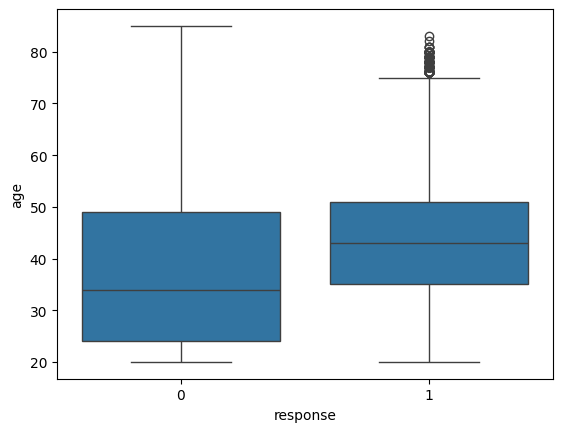

In [17]:
#'age'
sns.boxplot(x='response', y='age', data=df4)

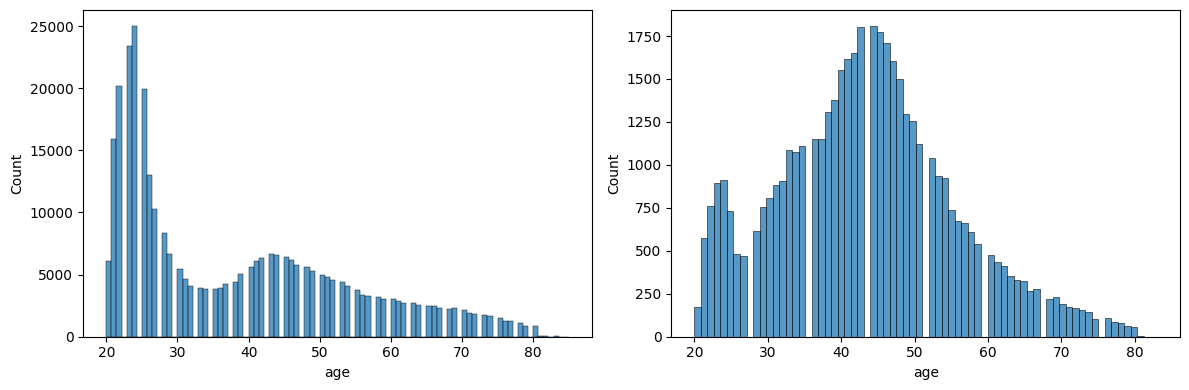

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

aux0 = df4.loc[df4['response'] == 0, 'age']
sns.histplot(aux0, ax=ax1)

aux1 = df4.loc[df4['response'] == 1, 'age']
sns.histplot(aux1, ax=ax2)

plt.tight_layout()
plt.show()

### 4.1.1 Gender

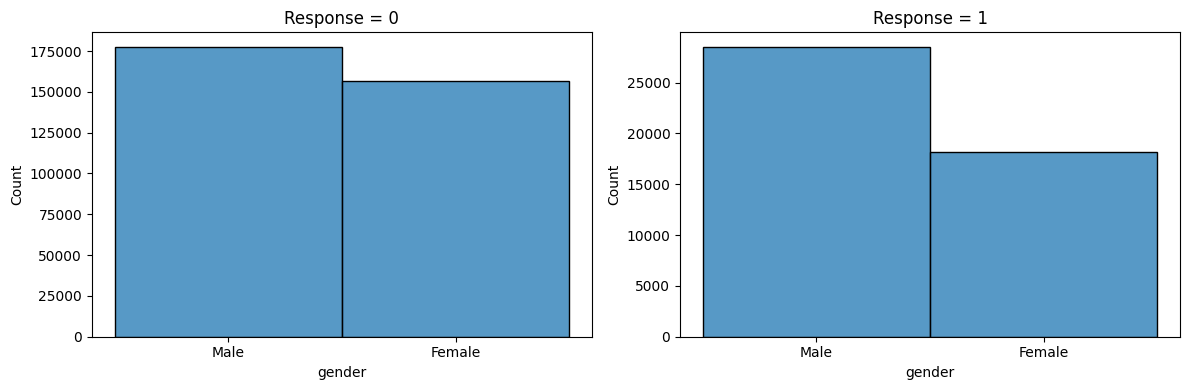

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

aux0 = df4.loc[df4['response'] == 0, 'gender']
sns.histplot(aux0, ax=ax1)
ax1.set_title('Response = 0')

aux1 = df4.loc[df4['response'] == 1, 'gender']
sns.histplot(aux1, ax=ax2)
ax2.set_title('Response = 1')

plt.tight_layout()
plt.show()

### 4.1.3 annual_premium

<Axes: xlabel='response', ylabel='annual_premium'>

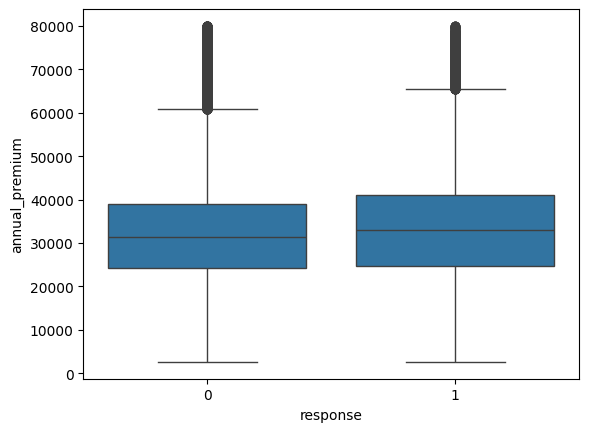

In [20]:
aux2 = df4[df4['annual_premium'] < 80000]
sns.boxplot(x='response', y='annual_premium', data=aux2)

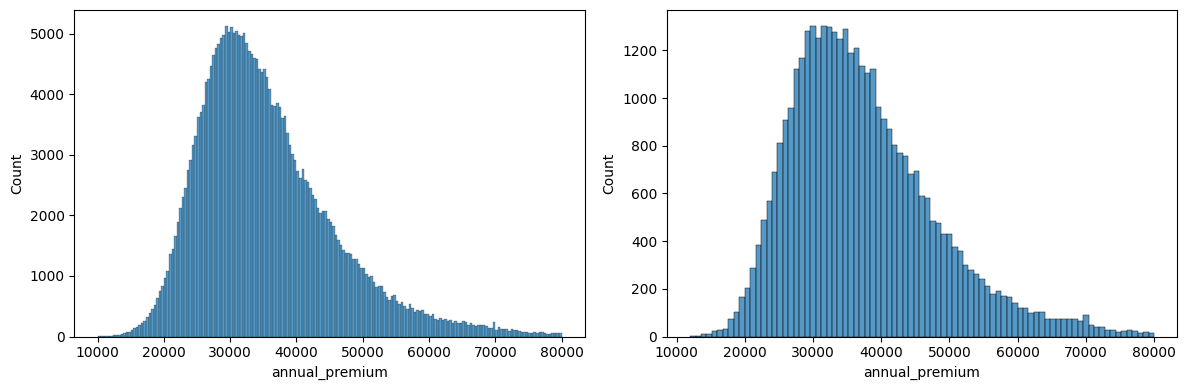

In [21]:
aux2 = df4[(df4['annual_premium'] > 10000) & (df4['annual_premium'] < 80000)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

aux0 = aux2.loc[aux2['response'] == 0, 'annual_premium']
sns.histplot(aux0, ax=ax1)

aux1 = aux2.loc[aux2['response'] == 1, 'annual_premium']
sns.histplot(aux1, ax=ax2)

plt.tight_layout()
plt.show()

### 4.1.3 driving_license

<Axes: xlabel='response', ylabel='driving_license'>

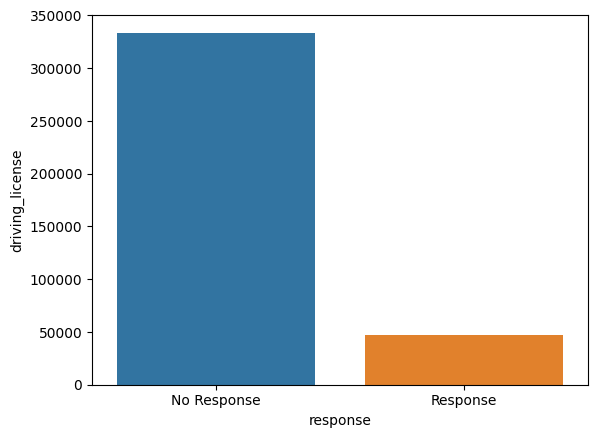

In [22]:
aux = df4[['driving_license', 'response']].groupby('response').sum().reset_index()
aux['response'] = aux['response'].map({0: 'No Response', 1: 'Response'})
sns.barplot(x='response', y='driving_license', data=aux, hue='response')

In [23]:
aux['driving_license_percent'] = aux['driving_license'] / aux['driving_license'].sum()
aux.head()

,response,driving_license,driving_license_percent
0,No Response,333628,0.877283
1,Response,46669,0.122717


### 4.1.4 region_code

<Axes: xlabel='region_code', ylabel='id'>

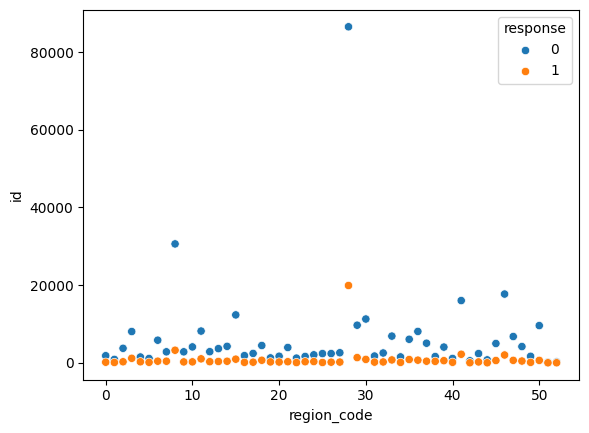

In [24]:
aux4 = df4[['id','region_code','response']].groupby(['region_code','response']).count().reset_index()
sns.scatterplot(x='region_code', y='id', hue='response',data=aux4)

### 4.1.5 previously_insured

In [25]:
pd.crosstab(df4['previously_insured'], df4['response']).apply(lambda x: x/x.sum(), axis=1)

response,0,1
previously_insured,,
0,0.774546,0.225454
1,0.999095,0.000905


### 4.1.6 vehicle_age

In [26]:
df4[['vehicle_age','response']].value_counts(normalize=True).reset_index()

,vehicle_age,response,proportion
0,between_1_2_years,0,0.434285
1,below_1_year,0,0.413488
2,between_1_2_years,1,0.091328
3,over_2_years,0,0.029663
4,below_1_year,1,0.018897
5,over_2_years,1,0.012338


### 4.1.8 policy_sales_channel

<Axes: xlabel='response', ylabel='policy_sales_channel'>

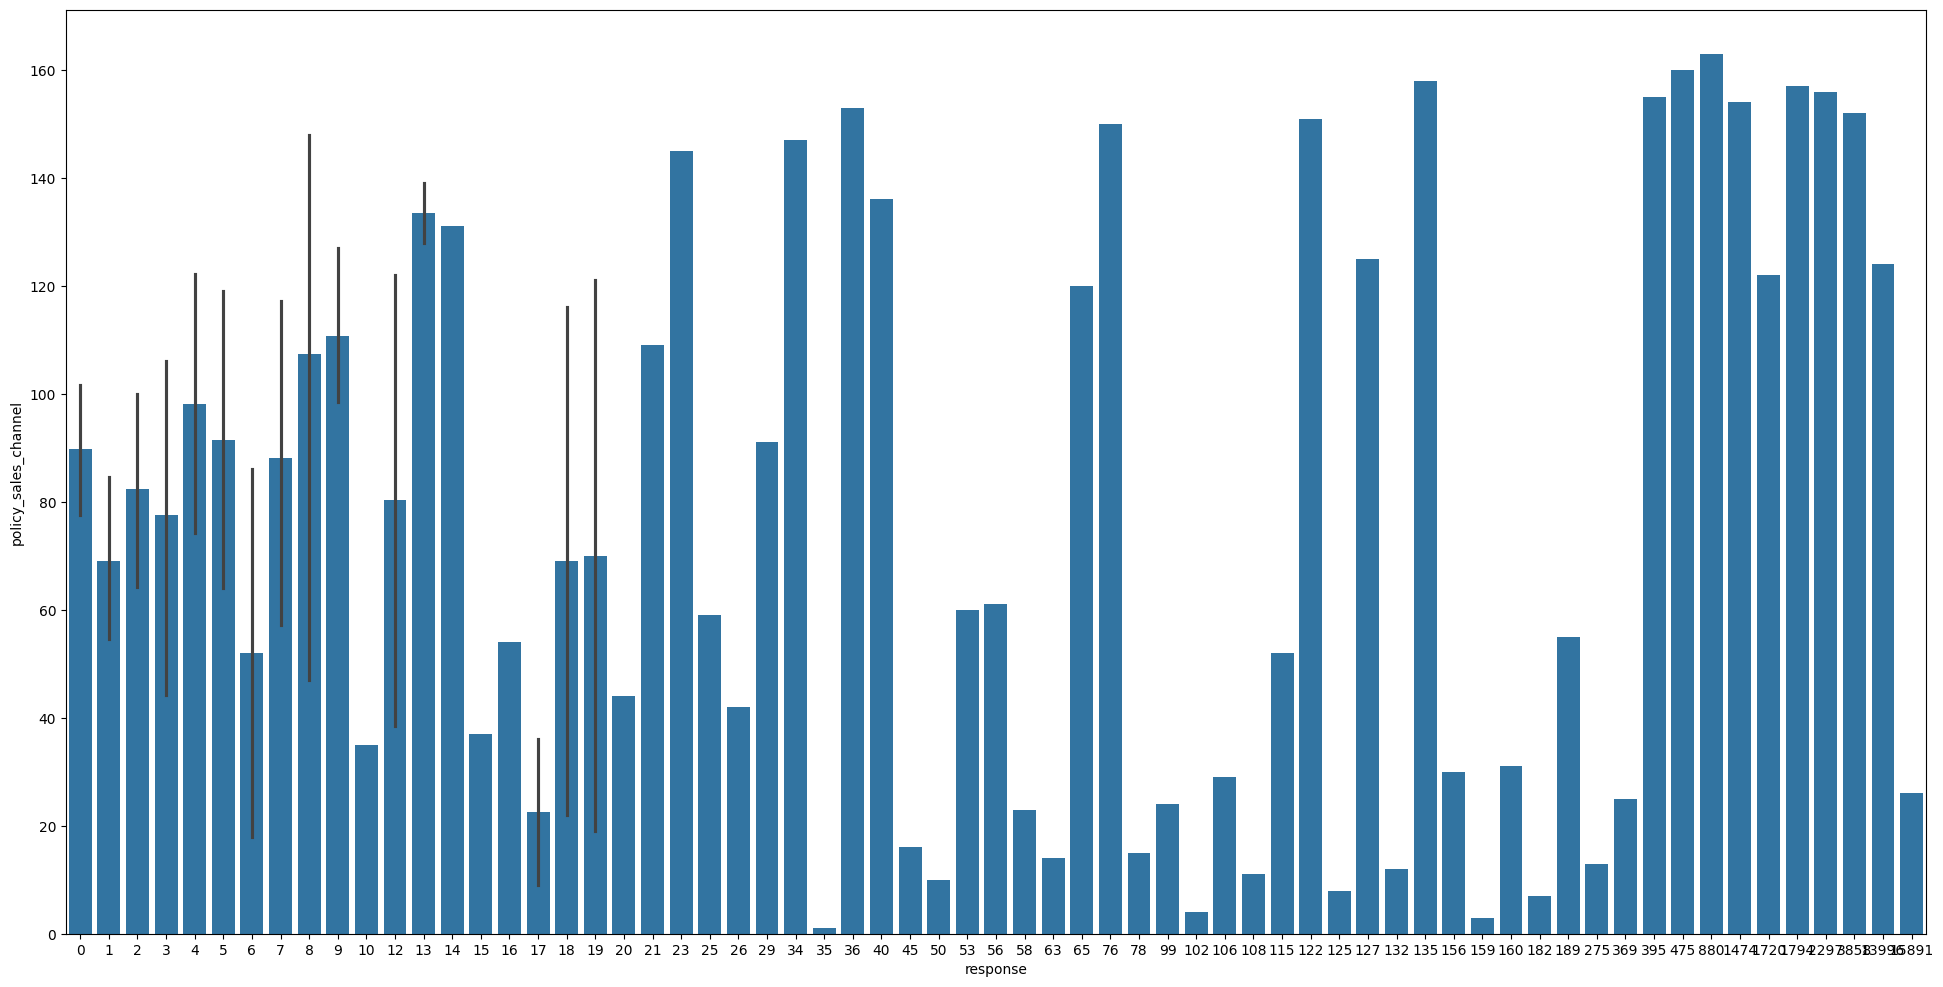

In [27]:
aux5 = df4[['policy_sales_channel','response']].groupby('policy_sales_channel').sum().reset_index()
plt.figure(figsize=(24,12))
sns.barplot(x='response', y='policy_sales_channel', data=aux5)

### 4.1.9 vintage

<Axes: xlabel='response', ylabel='vintage'>

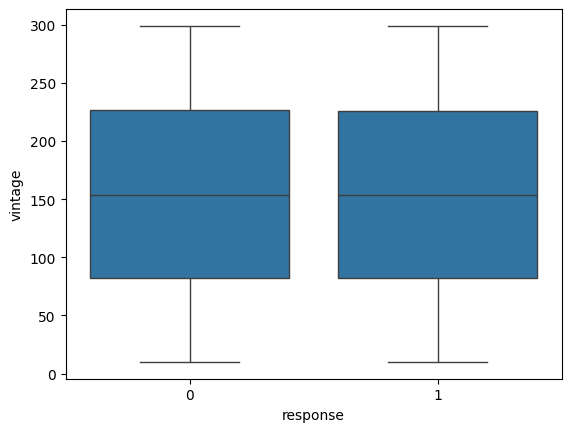

In [28]:
sns.boxplot(x='response', y='vintage', data=df4)

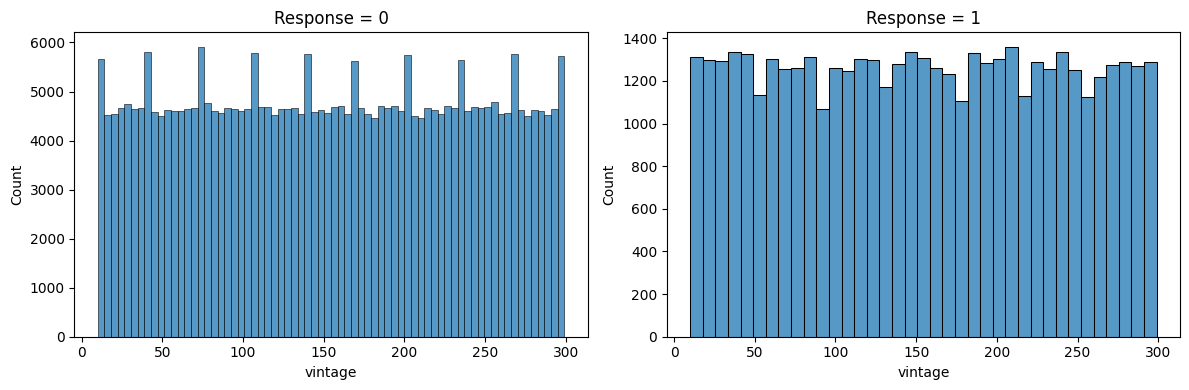

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

aux7 = df4.loc[df4['response'] == 0, 'vintage']
sns.histplot(aux7, ax=ax1)
ax1.set_title('Response = 0')

aux8 = df4.loc[df4['response'] == 1, 'vintage']
sns.histplot(aux8, ax=ax2)
ax2.set_title('Response = 1')

plt.tight_layout()
plt.show()

## 4.2 Analise bivariada

## 4.3 Analise multivariada

# 5.0 DATA PREPARATION

In [30]:
df5 = df4.copy()

In [31]:
x = df4.drop('response', axis=1)
y = df4['response'].copy()

x_train, x_validation, y_train, y_validation = ms.train_test_split(x, y, test_size=0.2, random_state=42)

x_val = x_validation.copy()
 
df5 = pd.concat([x_train, y_train], axis=1)

## 5.1 Standardization

In [32]:
ss = pp.StandardScaler()
#annual_premium
df5["annual_premium"] = ss.fit_transform(df5[["annual_premium"]])
pickle.dump(ss, open('../src/features/annual_premium_scaler.pkl','wb'))

## 5.2 Rescaling

In [33]:
#age (com o grafico histplot ficou evidente que precisa do rescaling)
mms_age = pp.MinMaxScaler()
df5["age"] = mms_age.fit_transform(df5[["age"]])
pickle.dump(mms_age, open('../src/features/age_scaler.pkl','wb'))

#vintage
mms_vintage = pp.MinMaxScaler()
df5["vintage"] = mms_vintage.fit_transform(df5[["vintage"]])
pickle.dump(mms_vintage, open('../src/features/vintage_scaler.pkl','wb'))

## 5.3 Encoder

In [34]:
# gender - One Hot Encoding / Target Encoding
target_encode_gender = df5.groupby( 'gender' )['response'].mean()
df5['gender'] = df5['gender'].map( target_encode_gender ).astype(float)
pickle.dump( target_encode_gender, open( '../src/features/target_encode_gender_scaler.pkl', 'wb' ) )

# region_code - Target Encoding / Frequency Encoding
target_encode_region_code = df5.groupby( 'region_code' )['response'].mean()
df5.loc[:, 'region_code'] = df5['region_code'].map( target_encode_region_code )
pickle.dump( target_encode_region_code, open( '../src/features/target_encode_region_code_scaler.pkl', 'wb' ) )

# vehicle_age - One Hot Encoding / Frequency Encoding
df5 = pd.get_dummies( df5, prefix='vehicle_age', columns=['vehicle_age'] )

# policy_sales_channel - Target Encoding / Frequency Encoding
fe_policy_sales_channel = df5.groupby( 'policy_sales_channel' ).size() / len( df5 )
df5.loc[:, 'policy_sales_channel'] = df5['policy_sales_channel'].map( fe_policy_sales_channel )
pickle.dump( fe_policy_sales_channel, open( '../src/features/fe_policy_sales_channel_scaler.pkl', 'wb' ) )

## 5.4 Validation Preparation

In [35]:
# gender
x_validation['gender'] = x_validation['gender'].map( target_encode_gender ).astype(float)

# age
x_validation['age'] = mms_age.transform(x_validation[['age']]).ravel().astype(float)

# region_code
x_validation.loc[:, 'region_code'] = x_validation.loc[:, 'region_code'].map( target_encode_region_code )

# vehicle_age
x_validation = pd.get_dummies( x_validation, prefix='vehicle_age', columns=['vehicle_age'] )

# annual_premium
x_validation.loc[:, 'annual_premium'] = ss.transform( x_validation[['annual_premium']].values )

# policy_sales_channel
x_validation.loc[:, 'policy_sales_channel'] = x_validation['policy_sales_channel'].map( fe_policy_sales_channel )

# vintage
x_validation['vintage'] = mms_vintage.transform(x_validation[['vintage']]).ravel().astype(float)

# fillna
x_validation = x_validation.fillna( 0 )

/home/ds-eduardo/.pyenv/versions/propensao/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# 6.0 FEATURE SELECTION

## 6.0.1 Boruta algoritmo

In [36]:
x_train_n = df5.drop(['id', 'response'], axis=1)
y_train_n = y_train.values.ravel()

#define model
et = en.ExtraTreesClassifier(n_jobs=-1)

#define boruta

boruta = bt(
    estimator=et,
    n_estimators='auto',
    verbose=2,
    random_state=42
).fit(x_train_n, y_train_n)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	9 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	10 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	11 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	12 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	13 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	14 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	15 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
Iteration: 	16 / 100
Confirmed: 	1
Tentative: 	1
Rejected: 	10
I

In [37]:
col_selected_boruta = boruta.support_.tolist()

#best features
x_train_f5 = df5.drop(['id','response'], axis=1)
col_selected_boruta = x_train_f5.iloc[:,col_selected_boruta].columns.to_list()

cols_not_selected_boruta = list(np.setdiff1d(x_train_f5.columns, col_selected_boruta))

## 6.1 Feature importance

In [38]:
#Data preparation
x_train_n = df5.drop(['id', 'response'], axis=1)
y_train_n = y_train.values


# Model definition
forest = en.ExtraTreesClassifier(n_estimators=250, random_state=0, n_jobs=-1)
forest.fit(x_train_n, y_train_n)
 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

Feature Ranking:
                         feature  importance
0                        vintage    0.273060
0                 annual_premium    0.245104
0                            age    0.164858
0                    region_code    0.106965
0                 vehicle_damage    0.066324
0           policy_sales_channel    0.059156
0             previously_insured    0.057517
0       vehicle_age_below_1_year    0.013606
0  vehicle_age_between_1_2_years    0.006103
0                         gender    0.004627
0       vehicle_age_over_2_years    0.002176
0                driving_license    0.000503


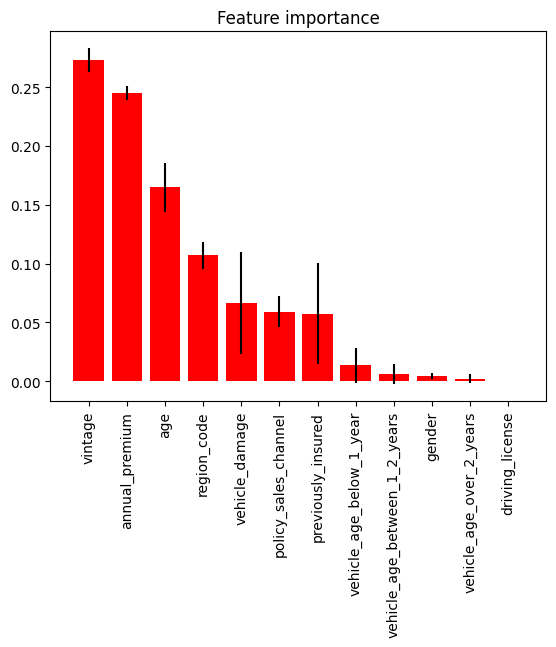

In [39]:
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

#print feature ranking
print("Feature Ranking:")
df = pd.DataFrame()
for i, j in zip(x_train_n, forest.feature_importances_):
    aux = pd.DataFrame({'feature': i, 'importance': j}, index=[0])
    df = pd.concat([df, aux], axis=0)

print(df.sort_values('importance', ascending=False))

#plot figure
plt.figure()
plt.title("Feature importance")
plt.bar(range(x_train_n.shape[1]), importances[indices], color='r', yerr=std[indices], align='center')
plt.xticks(range(x_train_n.shape[1]),x_train_n.columns[indices],rotation=90)
plt.xlim([-1,x_train_n.shape[1]])
plt.show()

# 7.0 MACHINE LEARNING MODEL

In [40]:
col_selected = ['vintage', 'annual_premium', 'age', 'region_code', 'vehicle_damage', 'policy_sales_channel', 'previously_insured']

x_train = df5[col_selected]
x_val = x_validation[col_selected]

## 7.1 KNN

In [41]:
knn_model = ng.KNeighborsClassifier(n_neighbors=7)

knn_model.fit(x_train, y_train)

yhat_knn = knn_model.predict_proba(x_val)
y_score = yhat_knn[:, 1]

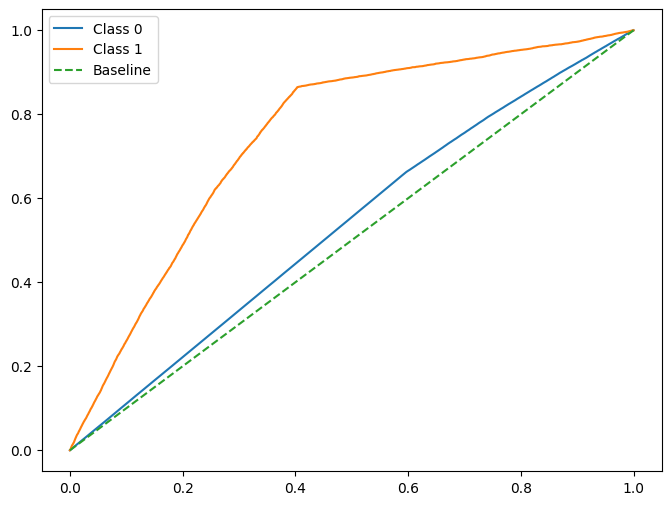

In [42]:
# classe 1 (positivos)
x1, y1 = cumulative_gain_curve(y_validation, y_score)

# classe 0
x0, y0 = cumulative_gain_curve(1 - y_validation, 1 - y_score)

plt.figure(figsize=(8,6))
plt.plot(x0, y0, label='Class 0')
plt.plot(x1, y1, label='Class 1')
plt.plot(x1, x1, '--', label='Baseline')

plt.legend()
plt.show()

## 7.2 Regressão Logistica

In [43]:
model_rl = lm.LogisticRegression(random_state=42)

model_rl.fit(x_train, y_train)

yhat_lr = model_rl.predict_proba(x_val)

y_score = yhat_lr[:, 1]

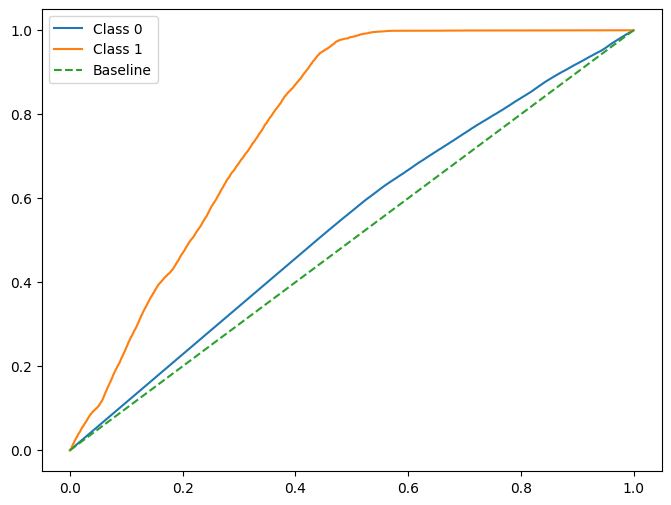

In [44]:
# classe 1 (positivos)
x1, y1 = cumulative_gain_curve(y_validation, y_score)

# classe 0
x0, y0 = cumulative_gain_curve(1 - y_validation, 1 - y_score)

plt.figure(figsize=(8,6))
plt.plot(x0, y0, label='Class 0')
plt.plot(x1, y1, label='Class 1')
plt.plot(x1, x1, '--', label='Baseline')

plt.legend()
plt.show()

## 7.3 Extra trees

In [45]:
#model definition
et = en.ExtraTreesClassifier(n_estimators=1000, n_jobs=-1, random_state=42)

#model fit
et.fit(x_train, y_train)

#model predict
yhat_et = et.predict_proba(x_val)
y_score = yhat_et[:, 1]

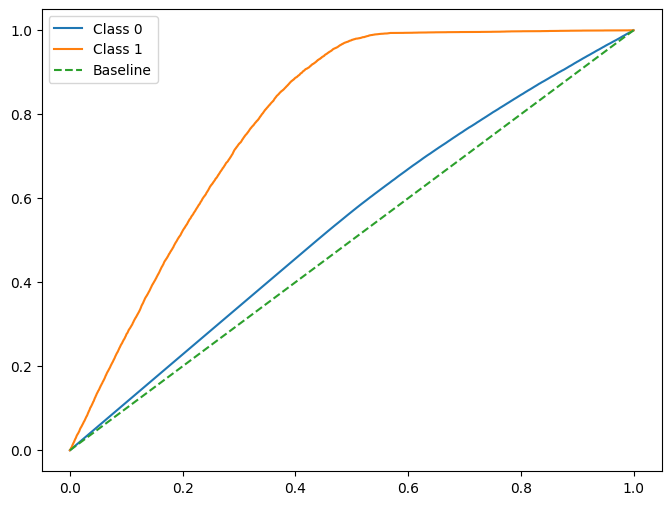

In [46]:
# classe 1 (positivos)
x1, y1 = cumulative_gain_curve(y_validation, y_score)

# classe 0
x0, y0 = cumulative_gain_curve(1 - y_validation, 1 - y_score)

plt.figure(figsize=(8,6))
plt.plot(x0, y0, label='Class 0')
plt.plot(x1, y1, label='Class 1')
plt.plot(x1, x1, '--', label='Baseline')

plt.legend()
plt.show()

## 7.4 Random Forest

In [47]:
rf = en.RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=42)

rf.fit(x_train, y_train)

yhat_rf = rf.predict_proba(x_val)
y_score = yhat_rf[:, 1]

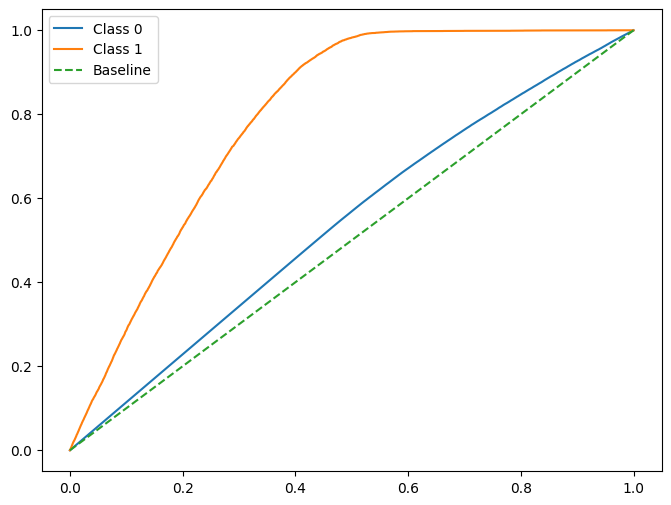

In [48]:
# classe 1 (positivos)
x1, y1 = cumulative_gain_curve(y_validation, y_score)

# classe 0
x0, y0 = cumulative_gain_curve(1 - y_validation, 1 - y_score)

plt.figure(figsize=(8,6))
plt.plot(x0, y0, label='Class 0')
plt.plot(x1, y1, label='Class 1')
plt.plot(x1, x1, '--', label='Baseline')

plt.legend()
plt.show()

# 8.0 MODEL PERFORMACE

In [49]:
df6 = x_validation.copy()
df6['response'] = y_validation.copy()

# propensity score
df6['score_knn'] = yhat_knn[:, 1].tolist()
df6['score_lr'] = yhat_lr[:, 1].tolist()
df6['score_ET'] = yhat_et[:, 1].tolist()

#sorted clients by propensity score
df6 = df6.sort_values('score_knn', ascending=False)

#compute precision at k
precision_k, data = precision_at_k(df6, k=20)

#compute recall at k
recall_k, data = recall_at_k(df6, k=15)

In [50]:
y_true = np.array([0,1,2,2])

y_score = np.array([[0.5, 0.2, 0.2],  # 0 is in top 2
                    [0.3, 0.4, 0.2],  # 1 is in top 2
                    [0.2, 0.4, 0.3],  # 2 is in top 2
                    [0.7, 0.2, 0.1]]) # 2 isn't in top 2

top_k_accuracy_score(y_true, y_score, k=2)

0.75

In [51]:
y_true = np.array([1,0,1,1,0,1,0,0])
y_score = np.array([])

## 8.1 Cumulative gain manually

<Axes: xlabel='base_cum_perc', ylabel='real_cum_perc'>

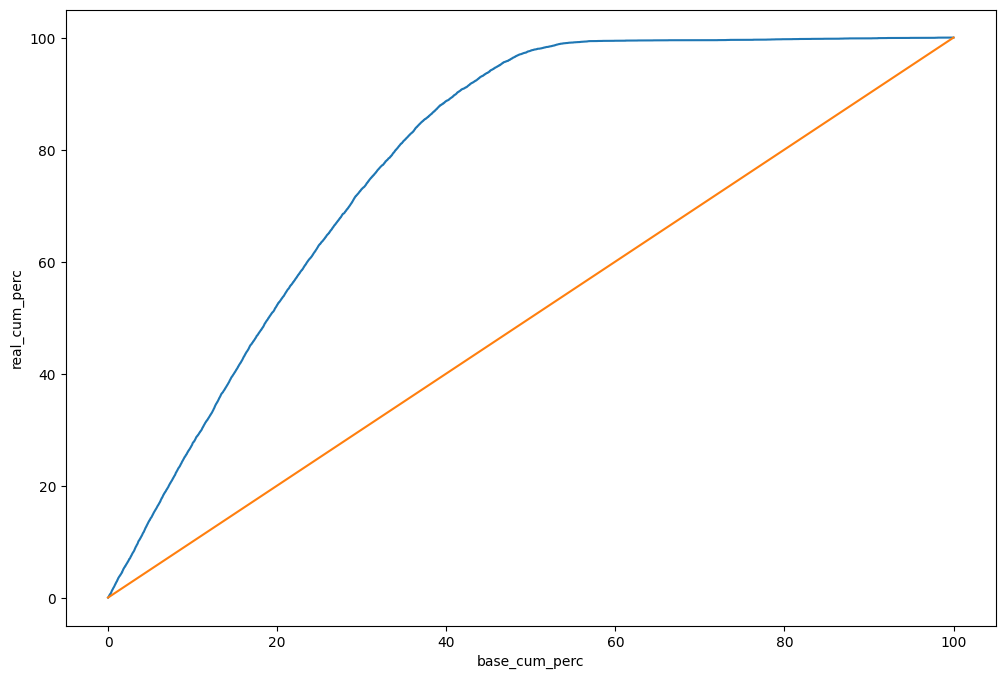

In [52]:
results = pd.DataFrame()
results['prediction'] = yhat_et[:,1].tolist()
results['real'] = y_validation.tolist()

results = results.sort_values('prediction', ascending=False)

results['real_cum'] = results['real'].cumsum()
results['real_cum_perc'] = 100*results['real_cum'] / results['real'].sum()

results['base'] = range(1, len( results ) + 1 )
results['base_cum_perc'] = 100*results['base'] / len(results)

results['baseline'] = results ['base_cum_perc']

plt.figure (figsize=(12,8))
sns.lineplot(x ='base_cum_perc', y='real_cum_perc', data=results)
sns.lineplot(x ='base_cum_perc', y='baseline', data=results)

## 8.2 lift curve manualy

<Axes: xlabel='base_cum_perc', ylabel='lift'>

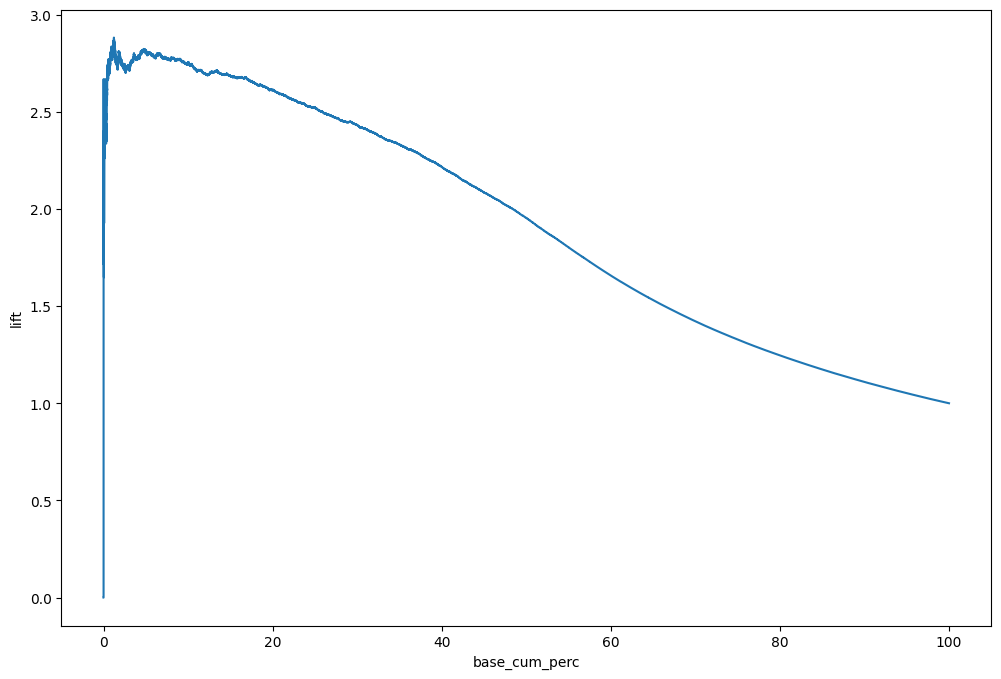

In [53]:
results = pd.DataFrame()
results['prediction'] = yhat_et[:,1].tolist()
results['real'] = y_validation.tolist()

results = results.sort_values('prediction', ascending=False)

results['real_cum'] = results['real'].cumsum()
results['real_cum_perc'] = 100*results['real_cum'] / results['real'].sum()

results['base'] = range(1, len( results ) + 1 )
results['base_cum_perc'] = 100*results['base'] / len(results)

results['baseline'] = results ['base_cum_perc']

results['lift'] = results['real_cum_perc'] / results['base_cum_perc']

plt.figure (figsize=(12,8))
sns.lineplot(x ='base_cum_perc', y='lift', data=results)

## 8.4 Compute bucket

In [54]:
# Compute bucket
results['bucket'] = results['prediction'].apply(
    lambda x: 0.9 if x >= 0.90 else
              0.8 if (x >= 0.80) & (x < 0.90) else
              0.7 if (x >= 0.70) & (x < 0.80) else
              0.6 if (x >= 0.60) & (x < 0.70) else
              0.5 if (x >= 0.50) & (x < 0.60) else
              0.4 if (x >= 0.40) & (x < 0.50) else
              0.3 if (x >= 0.30) & (x < 0.40) else
              0.2 if (x >= 0.20) & (x < 0.30) else
              0.1 if (x >= 0.10) & (x < 0.20) else 0.01
)

# Aggregate clients among buckets
df = results[['prediction', 'bucket']].groupby('bucket').agg({'min','count'}).reset_index()

df.columns = df.columns.droplevel()
df.columns = ['index', 'clients', 'propensity_score']

# Compute revenue and cost
df['gross_revenue'] = 40 * df['clients'] * df['propensity_score']
df['cost'] = 4 * df['clients']

df['base'] = df['clients'].sort_values(ascending=True).cumsum() / df['clients'].sum()

# Revenue
df['revenue'] = df['gross_revenue'] - df['cost']
df = df.sort_values('index', ascending=False)
df

,index,clients,propensity_score,gross_revenue,cost,base,revenue
9,0.90,134,0.9,4824.0,536,0.001758,4288.0
8,0.80,267,0.8,8544.0,1068,0.005261,7476.0
7,0.70,569,0.7,15932.0,2276,0.012726,13656.0
6,0.60,1155,0.6,27720.0,4620,0.027879,23100.0
5,0.50,1938,0.5,38760.0,7752,0.053305,31008.0
4,0.40,3431,0.4,54896.0,13724,0.098318,41172.0
3,0.30,5153,0.3,61836.0,20612,0.165923,41224.0
2,0.20,6981,0.2,55848.0,27924,0.257511,27924.0
1,0.10,8335,0.1,33340.0,33340,0.366863,0.0
0,0.01,48259,0.0,0.0,193036,1.000000,-193036.0


<Axes: xlabel='base', ylabel='revenue'>

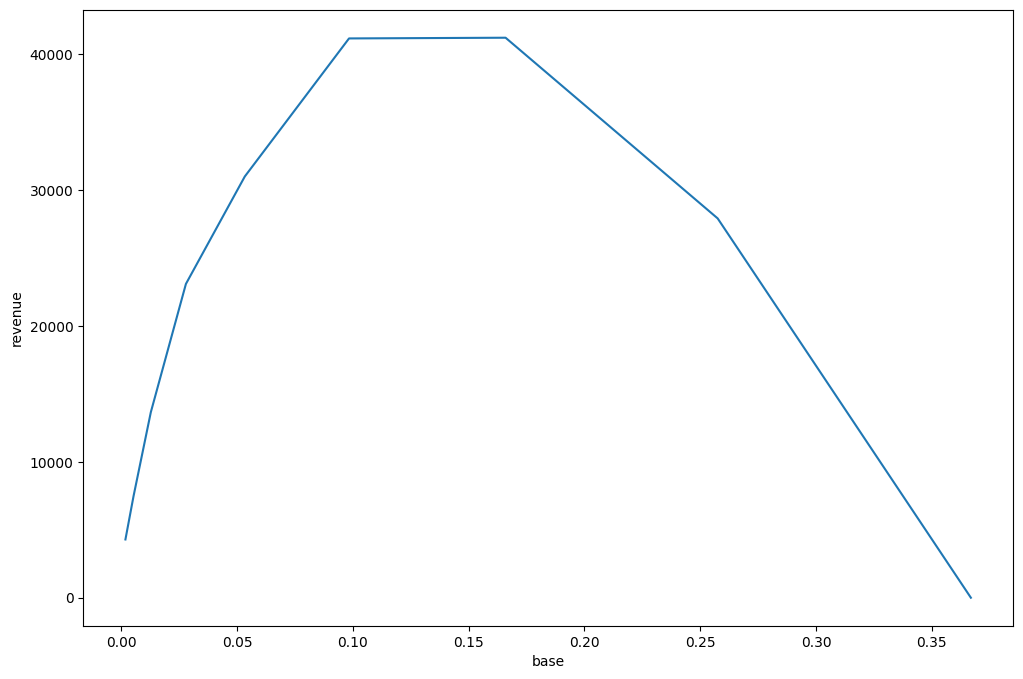

In [55]:
plt.figure(figsize=(12,8))
aux = df[df['propensity_score'] >=0.1]
sns.lineplot(x='base', y='revenue', data=aux)

# 9.0 DEPLOY TO PRODUCTION

In [57]:
pickle.dump(model_rl, open('/home/ds-eduardo/propensao_classificacao/src/models/model_health_insurance.pkl','wb'))

In [ ]:
import pickle
import pandas as pd
import numpy as np

class Healthinsurance:
    def __init__(self):
        self.home_path = '/home/ds-eduardo/propensao_classificacao/'
        self.annual_premium_scaler =                 pickle.load(open(self.home_path + 'src/features/annual_premium_scaler.pkl'))
        self.age_scaler =                            pickle.load(open(self.home_path + 'src/features/age_scaler.pkl'))
        self.vintage_scaler =                        pickle.load(open(self.home_path + 'src/features/vintage_scaler.pkl'))
        self.target_encode_gender_scaler =           pickle.load(open(self.home_path + 'src/features/target_encode_gender_scaler.pkl'))
        self.target_encode_region_code_scaler =      pickle.load(open(self.home_path + 'src/features/target_encode_region_code_scaler.pkl'))
        self.fe_policy_sales_channel_scaler =        pickle.load(open(self.home_path + 'src/features/fe_policy_sales_channel_scaler.pkl'))
    
    def data_cleaning(df1):

        #rename coloumns
        df_raw.columns = df_raw.columns.str.lower()

        #rename
        df1 = df_raw
        return df1

    def feature_engineering(df2):

        # vehicle age
        df2['vehicle_age'] = df2['vehicle_age'].apply(lambda x:'over_2_years' if x== '> 2 Years' else 'between_1_2_years' if x =='1-2 Year' else 'below_1_year')
        # vehicle damage
        df2['vehicle_damage'] = df2['vehicle_damage'].apply(lambda x:1 if x =='Yes' else 0)

        return df2


    def data_preparation(df5):

        #annual_premium
        df5["annual_premium"] = self.annual_premium_scaler.transform(df5[["annual_premium"]])

        #age
        df5["age"] = self.age_scaler.transform(df5[["age"]])

        #vintage
        df5["vintage"] = self.vintage_scaler.transform(df5[["vintage"]])

        ## 5.3 Encoder
        # gender - One Hot Encoding / Target Encoding
        df5['gender'] = df5['gender'].map( self.target_encode_gender_scaler ).astype(float)

        # region_code - Target Encoding / Frequency Encoding
        df5.loc[:, 'region_code'] = df5['region_code'].map( self.target_encode_region_code_scaler )

        # vehicle_age - One Hot Encoding / Frequency Encoding
        df5 = pd.get_dummies( df5, prefix='vehicle_age', columns=['vehicle_age'] )

        # policy_sales_channel - Target Encoding / Frequency Encoding
        df5.loc[:, 'policy_sales_channel'] = df5['policy_sales_channel'].map( self.fe_policy_sales_channel_scaler )

        col_selected = ['vintage', 'annual_premium', 'age', 'region_code', 'vehicle_damage', 'policy_sales_channel', 'previously_insured']

        return df5[col_selected]
    
    def get_predict(self, model, original_data,test_data):
        #model predict
        pred = model.predict_proba(test_data)

        original_data['score'] = pred

        return original_data.to_json(orient='records', date_format='iso')

    


## 9.1 API Handler

In [ ]:
import pickle
import pandas as pd
from flask import Flask, request, Response
from healthinsurance.Healthinsurance import Healthinsurance

#loading model

model = pickle.load(open('src/models/model_health_insurance.pkl','rb'))

#inicialização
app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def health_insurance_predict():
    test_json = request.get_json()

    if test_json: # there is data
        if isinstance(test_json, dict): # unique example
            test_raw = pd.DataFrame(test_json, index=[0])

        else: # multiple example
            test_raw = pd.DataFrame(test_json, columns=test_json[0].keys())

        # Instantiate Rossmann class
        pipeline = HealthInsurance()

        # data cleaning
        df1 = pipeline.data_cleaning(test_raw)

        # feature engineering
        df2 = pipeline.feature_engineering(df1)

        # data preparation
        df3 = pipeline.data_preparation(df2)

        # prediction
        df_response = pipeline.get_prediction(model, test_raw, df3)

        return df_response

    else:
        return Response('{}', status=200, mimetype='application/json')


if __name__ == '__main__':
    app.run('0.0.0.0', debug=True)

ModuleNotFoundError: No module named 'Healthinsurance'